In [1]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

--2026-04-30 19:27:46--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-30 19:27:47--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  18.4MB/s    in 39s     

2026-04-30 19:28:28 (19.2 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-04-30 19:28:28--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [2]:
import os
import cv2
import numpy as np

IMAGE_SIZE = 128

images = []
masks = []

image_dir = "images"
mask_dir = "annotations/trimaps"

image_files = sorted(os.listdir(image_dir))

for img_file in image_files:
    base_name = os.path.splitext(img_file)[0]

    img_path = os.path.join(image_dir, img_file)
    mask_path = os.path.join(mask_dir, base_name + ".png")

    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    if img is None or mask is None:
        continue

    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

    mask[mask == 2] = 0
    mask[mask == 3] = 1
    mask[mask == 1] = 1

    images.append(img)
    masks.append(mask)

images = np.array(images) / 255.0
masks = np.array(masks)
masks = np.expand_dims(masks, axis=-1)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=42)

In [4]:
from tensorflow.keras import layers, Model

def unet_model(input_shape=(128,128,3)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)

    u4 = layers.UpSampling2D()(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs, outputs)

In [5]:
model = unet_model()

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=16)

Epoch 1/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 106s 212ms/step - accuracy: 0.7435 - loss: 0.5137 - val_accuracy: 0.7502 - val_loss: 0.5297
Epoch 2/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 59s 161ms/step - accuracy: 0.8202 - loss: 0.4064 - val_accuracy: 0.8346 - val_loss: 0.3791
Epoch 3/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.8437 - loss: 0.3604 - val_accuracy: 0.8492 - val_loss: 0.3472
Epoch 4/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.8583 - loss: 0.3300 - val_accuracy: 0.8572 - val_loss: 0.3309
Epoch 5/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.8711 - loss: 0.3049 - val_accuracy: 0.8734 - val_loss: 0.3028


In [8]:
y_test = y_test.astype('float32')

In [9]:
import tensorflow as tf

def iou_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return intersection / (union + 1e-7)

def dice_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    return (2 * tf.reduce_sum(y_true * y_pred)) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-7)

In [10]:
y_pred_unet = model.predict(X_test)

iou_unet = iou_score(y_test, y_pred_unet).numpy()
dice_unet = dice_score(y_test, y_pred_unet).numpy()

print("U-Net IoU:", iou_unet)
print("U-Net Dice:", dice_unet)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step
U-Net IoU: 0.7349874
U-Net Dice: 0.84725386


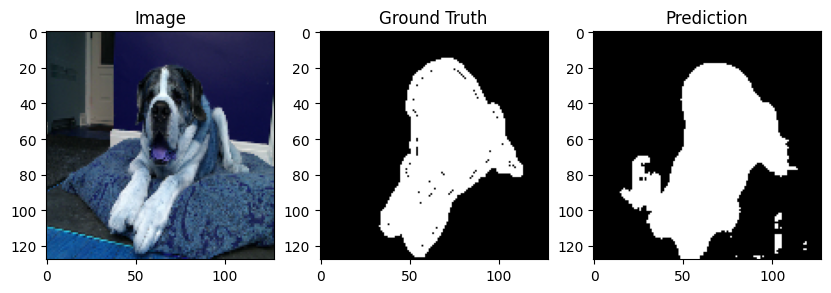

In [11]:
import matplotlib.pyplot as plt

def show_prediction(idx, preds):
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(X_test[idx])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y_test[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow((preds[idx] > 0.5).squeeze(), cmap='gray')
    plt.title("Prediction")

    plt.show()

show_prediction(3, y_pred_unet)

In [12]:
!pip install segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.7 MB/s eta 0:00:00


In [17]:
from tensorflow.keras import layers, Model

def fpn_model(input_shape=(128,128,3)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, padding='same', activation='relu')(p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, padding='same', activation='relu')(p2)

    c2_1x1 = layers.Conv2D(256, 1, padding='same')(c2)
    c1_1x1 = layers.Conv2D(256, 1, padding='same')(c1)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.add([u1, c2_1x1])

    u2 = layers.UpSampling2D()(u1)
    u2 = layers.add([u2, c1_1x1])

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(u2)

    return Model(inputs, outputs)

In [31]:
from tensorflow.keras import layers,Model

def resize_to_match(x, target):
    return tf.image.resize(x, size=(tf.shape(target)[1], tf.shape(target)[2]))

def psp_module(x):

    pool1 = layers.AveragePooling2D(pool_size=(1,1))(x)
    pool1 = layers.Conv2D(64, 1, activation='relu', padding='same')(pool1)

    pool2 = layers.AveragePooling2D(pool_size=(2,2))(x)
    pool2 = layers.Conv2D(64, 1, activation='relu', padding='same')(pool2)
    pool2 = layers.UpSampling2D(size=(2,2))(pool2)

    pool3 = layers.AveragePooling2D(pool_size=(4,4))(x)
    pool3 = layers.Conv2D(64, 1, activation='relu', padding='same')(pool3)
    pool3 = layers.UpSampling2D(size=(4,4))(pool3)

    return layers.concatenate([x, pool1, pool2, pool3])

def pspnet_model(input_shape=(128,128,3)):
    inputs = layers.Input(input_shape)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)

    x = psp_module(x)

    x = layers.UpSampling2D(size=(2,2))(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return Model(inputs, outputs)

In [32]:
fpn = fpn_model()
psp = pspnet_model()

for m in [fpn, psp]:
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
fpn.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=16)

Epoch 1/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - accuracy: 0.7168 - loss: 0.5437 - val_accuracy: 0.7648 - val_loss: 0.4918
Epoch 2/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.7734 - loss: 0.4774 - val_accuracy: 0.7936 - val_loss: 0.4452
Epoch 3/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.7867 - loss: 0.4536 - val_accuracy: 0.8022 - val_loss: 0.4331
Epoch 4/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.8015 - loss: 0.4300 - val_accuracy: 0.7953 - val_loss: 0.4380
Epoch 5/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.8060 - loss: 0.4225 - val_accuracy: 0.7979 - val_loss: 0.4311


In [34]:
psp.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=16)

Epoch 1/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.6964 - loss: 0.5697 - val_accuracy: 0.7510 - val_loss: 0.5152
Epoch 2/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7503 - loss: 0.5081 - val_accuracy: 0.7494 - val_loss: 0.5137
Epoch 3/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.7663 - loss: 0.4864 - val_accuracy: 0.7752 - val_loss: 0.4752
Epoch 4/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7733 - loss: 0.4741 - val_accuracy: 0.7689 - val_loss: 0.4978
Epoch 5/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7783 - loss: 0.4669 - val_accuracy: 0.7800 - val_loss: 0.4640


In [35]:
y_pred_fpn = fpn.predict(X_test)
y_pred_psp = psp.predict(X_test)

print("FPN IoU:", iou_score(y_test, y_pred_fpn).numpy())
print("PSP IoU:", iou_score(y_test, y_pred_psp).numpy())

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
FPN IoU: 0.624615
PSP IoU: 0.55694544


In [36]:
results = {
    "U-Net": (iou_score(y_test, y_pred_unet).numpy(), dice_score(y_test, y_pred_unet).numpy()),
    "FPN": (iou_score(y_test, y_pred_fpn).numpy(), dice_score(y_test, y_pred_fpn).numpy()),
    "PSPNet": (iou_score(y_test, y_pred_psp).numpy(), dice_score(y_test, y_pred_psp).numpy())
}

for k,v in results.items():
    print(k, "IoU:", v[0], "Dice:", v[1])

U-Net IoU: 0.7349874 Dice: 0.84725386
FPN IoU: 0.624615 Dice: 0.76893914
PSPNet IoU: 0.55694544 Dice: 0.7154335


In [37]:
import pandas as pd

df = pd.DataFrame(results, index=["IoU", "Dice"]).T
print(df)

             IoU      Dice
U-Net   0.734987  0.847254
FPN     0.624615  0.768939
PSPNet  0.556945  0.715433
